## Nội dung

- Feature engineering
- Phân cụm: KMeans, DBSCAN
- Kết hợp phân cụm và phân tích mô tả
- Kết hợp PCA và phân cụm
- Tập dữ liệu:
   1. Customer Personality Analysis (nguồn: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)
   2. Taxi geolocation (nguồn: https://www.coursera.org/projects/clustering-geolocation-data-intelligently-python)

**Sinh viên:** Phan Lê Huy Hoàng — **MSSV:** 24738541

#### Cài đặt thư viện

In [1]:
# Nếu thiếu thư viện: pip install numpy pandas matplotlib seaborn scikit-learn folium yellowbrick kneed setuptools
# Không cài lại thư viện mỗi lần chạy notebook.

### A. Customer Personality Analysis

#### A1. Đọc dữ liệu

In [2]:
import numpy as np
import pandas as pd

In [3]:
pd.set_option('display.max_columns', None)
customer_data = pd.read_csv('data/marketing_campaign.csv',
                           delimiter='\t', index_col='ID')
customer_data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


#### A2. Làm sạch
- Làm sạch dữ liệu.
- Trích xuất đặc trưng (đọc thêm: https://machinelearningcoban.com/general/2017/02/06/featureengineering/)

In [4]:
customer_data.info()

<class 'pandas.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   str    
 2   Marital_Status       2240 non-null   str    
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   str    
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int64  
 16  N

Dữ liệu khá sạch và chỉ có 1 số lượng nhỏ income bị thiếu dữ liệu, có thể xử lý bằng cách thêm vào mean. Mã hoá 1 số đặc trưng kiểu loại.

In [5]:
print('Số Income bị thiếu:', customer_data['Income'].isna().sum())
customer_data['Income'] = customer_data['Income'].fillna(customer_data['Income'].mean())

Số Income bị thiếu: 24


#### A3. Feature engineering

In [6]:
import datetime

Đầu tiên là dữ liệu liên quan ngày tháng.

- `Year_Birth` không phải là đặc trưng lý tưởng cho bài toán này, ta sẽ chuyển nó sang thành tuổi `Age` (tính từ hiện tại)

In [7]:
# Mốc cố định theo ngày làm bài để kết quả tái lập
reference_date = pd.Timestamp('2026-10-09')
customer_data['Age'] = reference_date.year - customer_data['Year_Birth']

- `Days_Since_Customer`, tương tự như `Year_Birth`, nên được chuyển thành số ngày đã tham gia `Enroll_days`.

In [8]:
customer_data['Dt_Customer'] = pd.to_datetime(customer_data['Dt_Customer'], format='%d-%m-%Y')
customer_data['Enroll_days'] = (reference_date - customer_data['Dt_Customer']).dt.days

- Các đặc trưng `Marital_Status`, `Kidhome`, `Teenhome` có thể được gom lại 1 thuộc tính duy nhất --> cô động hơn

In [9]:
# Tạo ra đặc trưng Fam_size (số người trong gia đình)
# bằng cách gộp các đặc trưng: Martial_Status, Kidhome, Teenhome
marital_map = {
    'Absurd': 1, 'Alone': 1,
    'YOLO': 1, 'Single': 1,
    'Married': 2, 'Together': 2,
    'Widow': 1, 'Divorced': 1
} # married/together->2 người, khác-> 1 người
customer_data['Marital_Status'] = customer_data['Marital_Status'].map(marital_map)
customer_data['Fam_Size'] = customer_data['Marital_Status'] + customer_data['Kidhome'] + customer_data['Teenhome'] 

- Gom các đặc trưng `AcceptedCmpX` thành 1 đặc trưng `Num_Accepted` (tổng)
- Làm tương tự cho các đặc trưng MntX, gom thành đặc trưng `MntTotal`

In [10]:
cmp_cols = [f'AcceptedCmp{i}' for i in range(1, 6)]
customer_data['Num_Accepted'] = customer_data[cmp_cols].sum(axis=1)

In [11]:
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
customer_data['MntTotal'] = customer_data[mnt_cols].sum(axis=1)

#### A4. Phân tích EDA

In [12]:
customer_data.describe()

,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,1.644643,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,57.194196,4838.582143,2.595089,0.297768,605.798214
min,1893.000000,1.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,30.000000,4485.000000,1.000000,0.000000,5.000000
25%,1959.000000,1.000000,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,49.000000,4665.750000,2.000000,0.000000,68.750000
50%,1970.000000,2.000000,51741.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,56.000000,4840.500000,3.000000,0.000000,396.000000
75%,1977.000000,2.000000,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,67.000000,5014.000000,3.000000,0.000000,1045.500000
max,1996.000000,2.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,133.000000,5184.000000,5.000000,4.000000,2525.000000
std,11.984069,0.478728,25037.797168,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,202.122512,0.906959,0.678381,602.249288


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

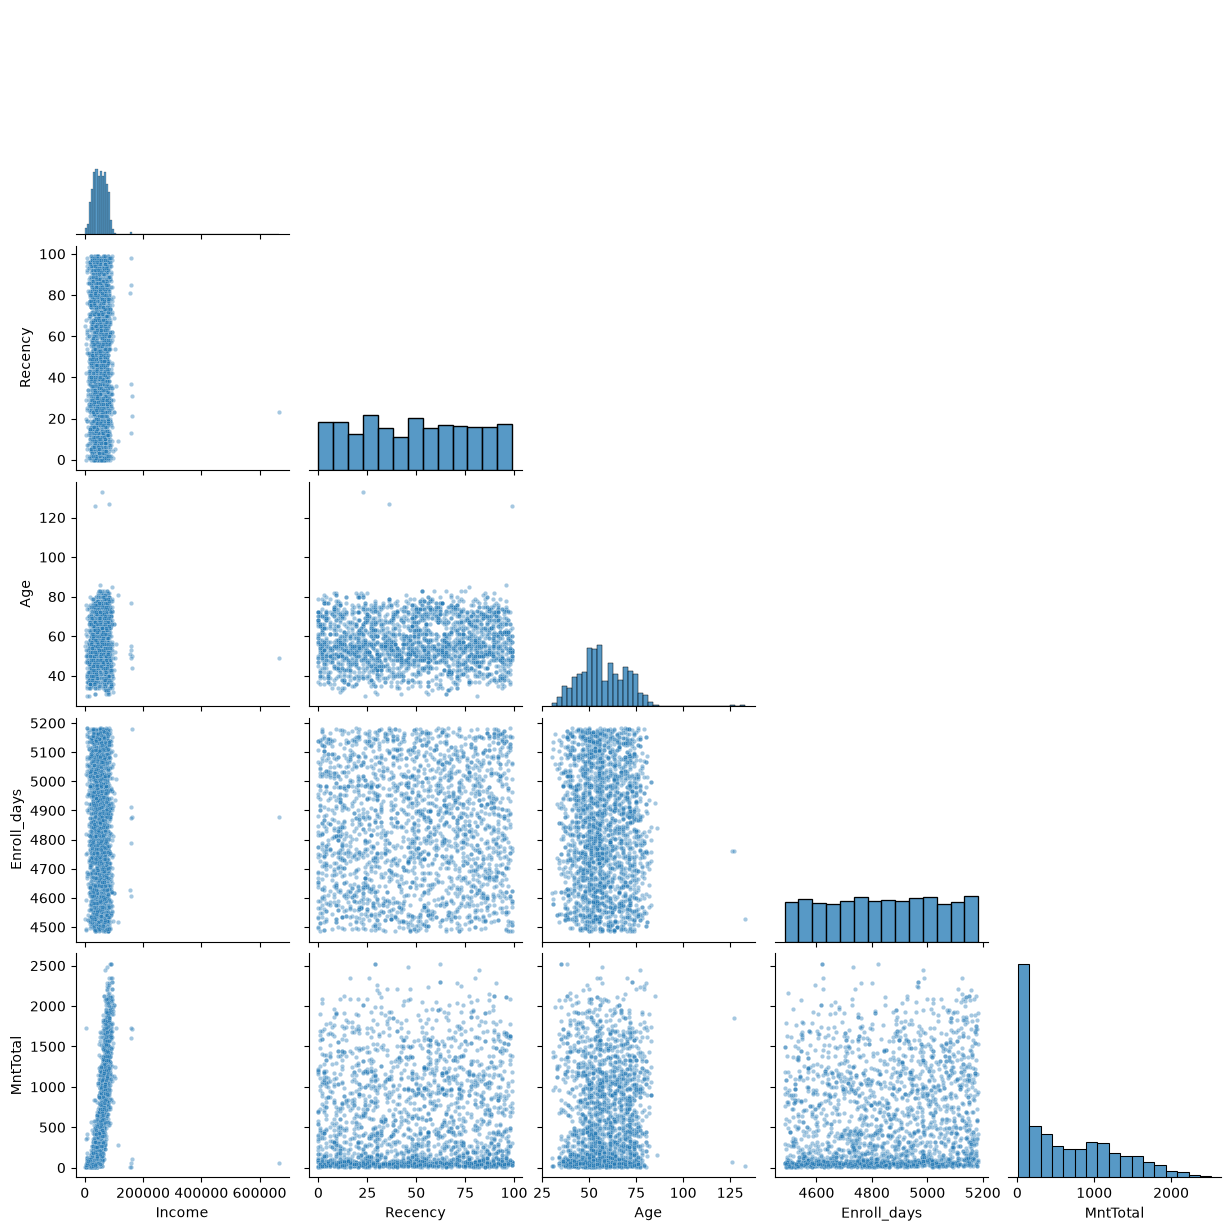

In [14]:
plot_cols = ['Income', 'Recency', 'Age', 'Enroll_days', 'MntTotal']
sns.pairplot(customer_data[plot_cols], corner=True, diag_kind='hist', plot_kws={'s': 10, 'alpha': 0.4})
plt.show()

In [15]:
# Loại tuổi trên 100 và thu nhập rất bất thường; không loại chỉ vì chi tiêu cao
n_before = len(customer_data)
customer_data = customer_data.loc[customer_data['Age'].between(18, 100) & customer_data['Income'].between(0, 200000)].copy()
print('Số dòng loại:', n_before - len(customer_data))

Số dòng loại: 4


In [16]:
import copy
df = customer_data.copy()

# Drop các cột không quan trọng
df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Complain', 'Response', 'Education', 'Num_Accepted'
], axis=1, inplace=True)

#### A5. Tiền xử lý

**Mã hoá đặc trưng kiểu loại**

In [17]:
# Các cột danh mục đã được gộp hoặc bỏ ở bước trên
print('Cột không phải số:', df.select_dtypes(exclude='number').columns.tolist())

Cột không phải số: []


**Chuẩn hoá các thuộc tính kiểu số**

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)

In [19]:
df.describe() # --> Kiểm tra mean và std có gần với giá trị (0, 1)?

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal
count,2.236000e+03,2.236000e+03,2.236000e+03,2236.000000,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03
mean,2.240307e-16,-7.149916e-17,1.271096e-17,0.000000,-7.308803e-17,-1.322734e-16,-1.525315e-16,6.514368e-17,1.150342e-15,2.192641e-16,4.766610e-18
std,1.000224e+00,1.000224e+00,1.000224e+00,1.000224,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00
min,-2.346560e+00,-1.696543e+00,-1.203575e+00,-1.470716,-9.110556e-01,-1.783046e+00,-2.192136e+00,-2.316276e+00,-1.750171e+00,-1.758810e+00,-9.987636e-01
25%,-7.688934e-01,-8.675502e-01,-6.861374e-01,-0.751127,-9.110556e-01,-8.600834e-01,-9.557071e-01,-6.924366e-01,-8.559730e-01,-6.565959e-01,-8.924037e-01
50%,-1.298227e-02,-4.016436e-03,-1.686996e-01,-0.031538,-2.268842e-01,-2.447750e-01,2.807217e-01,-9.417994e-02,1.101605e-02,4.456177e-01,-3.481402e-01
75%,7.620935e-01,8.595173e-01,3.487383e-01,0.688050,4.572872e-01,6.781877e-01,6.928646e-01,8.459377e-01,8.668740e-01,4.456177e-01,7.304157e-01
max,5.158923e+00,1.723051e+00,6.557993e+00,8.243731,8.667344e+00,2.216459e+00,6.050723e+00,2.469777e+00,1.707891e+00,2.650045e+00,3.189157e+00


#### A6. Phân cụm KMeans

In [20]:
from sklearn.cluster import KMeans

Phương pháp Elbow: ước lượng số cụm

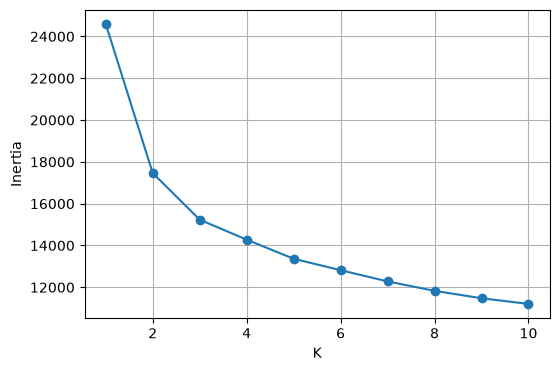

In [21]:
def plot_elbow(data):
    ks = list(range(1, 11))
    inertias = []
    for k in ks:
        model = KMeans(n_clusters=k, n_init=10, random_state=3000).fit(data)
        inertias.append(model.inertia_)
    plt.figure(figsize=(6, 4))
    plt.plot(ks, inertias, marker='o')
    plt.xlabel('K')
    plt.ylabel('Inertia')
    plt.grid(True)
    plt.show()
    return inertias

inertias = plot_elbow(df)

Sử dụng thư viện yellowbrick

In [22]:
from yellowbrick.cluster import KElbowVisualizer

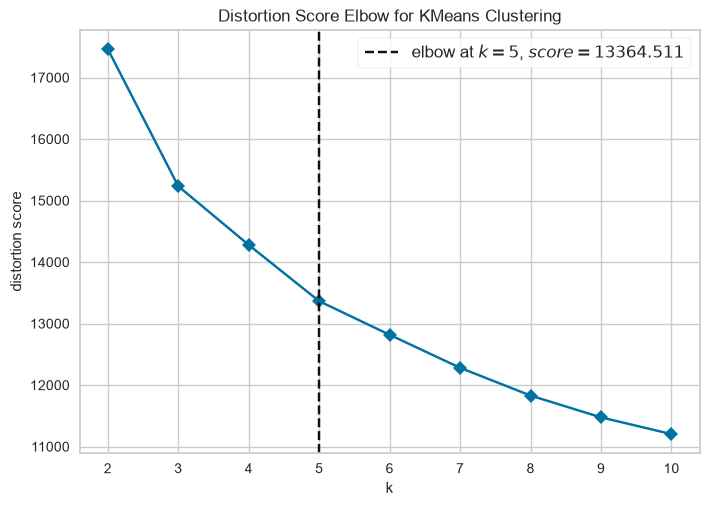

K gợi ý: 5


In [23]:
visualizer = KElbowVisualizer(KMeans(n_init=10, random_state=3000), k=(2, 11), timings=False, force_model=True)
visualizer.fit(df)
visualizer.show()
print('K gợi ý:', visualizer.elbow_value_)

**Phân cụm từ kết quả của phương pháp Elbow**

In [24]:
K_customer = visualizer.elbow_value_ or 5
kmean = KMeans(n_clusters=K_customer, n_init=10, random_state=3000).fit(df)
print('K chọn:', K_customer)
print('Số điểm theo cụm:', np.unique(kmean.labels_, return_counts=True))

K chọn: 5
Số điểm theo cụm: (array([0, 1, 2, 3, 4], dtype=int32), array([464, 487, 492, 238, 555]))


**Sử dụng PCA giảm số chiều dữ liệu --> trực quan hoá kết quả phân cụm**

In [25]:
from sklearn.decomposition import PCA

In [26]:
pca = PCA().fit(df)
scores = pca.transform(df)[:, :2]
print('Tỉ lệ phương sai 2 PC:', pca.explained_variance_ratio_[:2].sum())

Tỉ lệ phương sai 2 PC: 0.5248069871347196


**Trực quan hoá kết quả phân cụm**

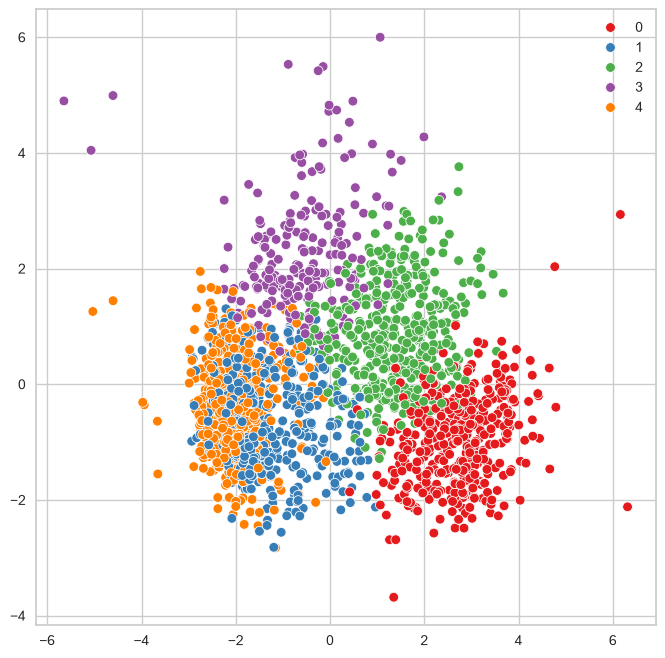

In [27]:
def visualize_cluster_result(scores, labels):
    '''
    Args:
        scores: biến đổi pca 2d
        labels: nhãn của từng điểm dữ liệu trong scores (chính là label của kết quả phân cụm)
    '''
    fig1, (axes) = plt.subplots(figsize=(8,8))
    scat_1 = sns.scatterplot(
                            x=scores[:,0],
                            y=scores[:,1],
                            hue=labels, ax=axes,
                            palette='Set1', legend='full'
            )
    plt.show()

visualize_cluster_result(scores, kmean.labels_)

#### Phân tích kết quả phân cụm (KMeans)

In [28]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_df = customer_data.copy()
kmean_df['Cluster'] = kmean.labels_
kmean_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,5148,1,0,1617,2
2174,1954,Graduation,1,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,4598,3,0,27,1
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,4797,2,0,776,2
6182,1984,Graduation,2,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,4624,3,0,53,4
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,4646,3,0,422,3


In [29]:
def visualize_cluster_distribution(labels):
    '''
    Args:
        labels: kết quả phân cụm (danh sách nhãn)
    '''
    ulabels, count = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6,4))

    colors = sns.color_palette('Set2')[0:5]
    
    labels = [f'Cluster {i}' for i in ulabels]
    plt.pie(count, 
            explode=[0.05]*len(ulabels), 
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            textprops=dict(color ="white", fontsize=10),
            counterclock=False,
            startangle=180,
            wedgeprops={"edgecolor":"gray",'linewidth': 1}
        )

    plt.axis('equal')
    plt.legend()
    plt.show()

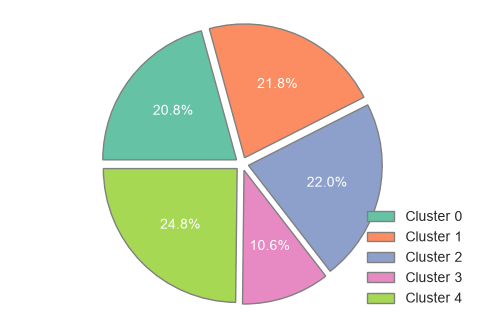

In [30]:
visualize_cluster_distribution(kmean.labels_)

**Phân tích đa biến + kết quả phân cụm**

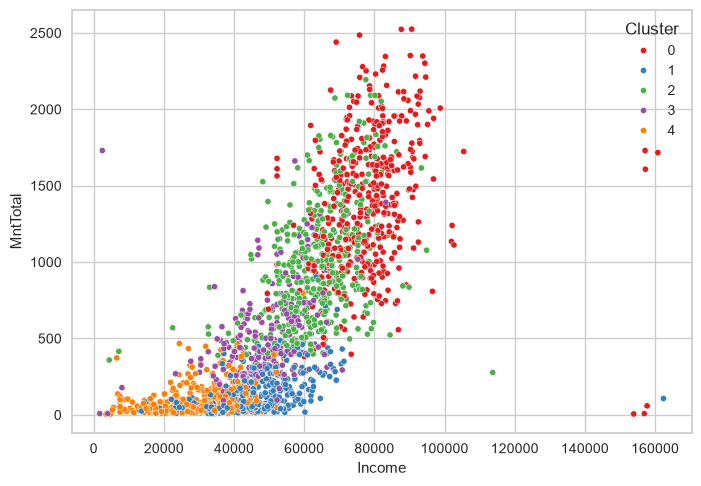

           Income  MntTotal  Fam_Size    Age  NumWebPurchases  \
Cluster                                                         
0        78384.29   1399.71      1.68  57.08             4.51   
1        43109.04    131.15      3.18  61.53             2.19   
2        63235.66    956.36      2.55  61.20             7.03   
3        48872.63    509.88      3.39  58.60             5.72   
4        28970.77     89.67      2.55  48.95             2.09   

         NumStorePurchases  
Cluster                     
0                     8.23  
1                     3.73  
2                     8.67  
3                     5.85  
4                     3.00  


In [31]:
sns.scatterplot(data=kmean_df, x='Income', y='MntTotal', hue='Cluster', palette='Set1', s=20)
plt.show()
print(kmean_df.groupby('Cluster')[['Income', 'MntTotal', 'Fam_Size', 'Age', 'NumWebPurchases', 'NumStorePurchases']].mean().round(2))

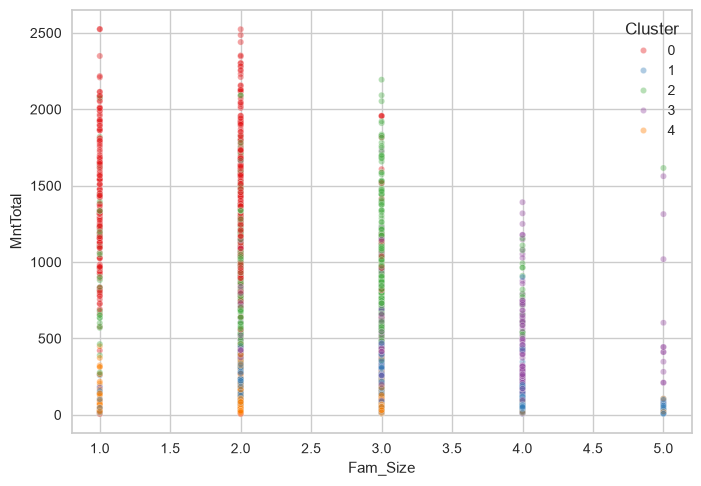

In [32]:
sns.scatterplot(data=kmean_df, x='Fam_Size', y='MntTotal', hue='Cluster', palette='Set1', s=20, alpha=0.4)
plt.show()

**Phân tích danh mục mua hàng**

         MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
Cluster                                                          
0          613.80      64.55           486.84            94.77   
1           69.23       5.42            27.85             7.40   
2          555.49      39.88           195.92            53.25   
3          302.80      13.53           105.48            21.55   
4           29.09       5.99            22.38             9.05   

         MntSweetProducts  MntGoldProds  
Cluster                                  
0                   65.62         74.14  
1                    5.49         15.76  
2                   41.53         70.28  
3                   15.70         50.83  
4                    5.88         17.29  


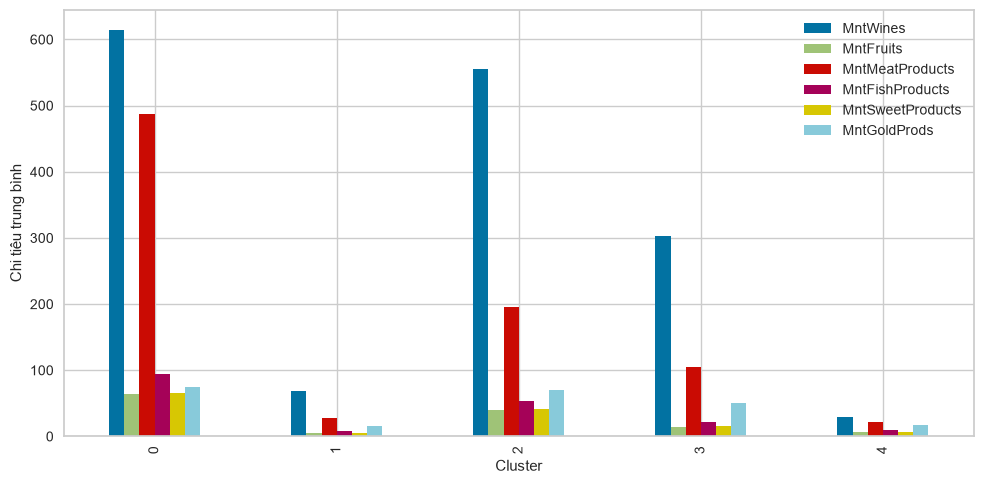

Danh mục ở đây là các nhóm sản phẩm; so sánh thêm số lần mua qua web, catalog và cửa hàng:
         NumWebPurchases  NumCatalogPurchases  NumStorePurchases
Cluster                                                         
0                   4.51                 6.28               8.23
1                   2.19                 0.78               3.73
2                   7.03                 3.79               8.67
3                   5.72                 2.28               5.85
4                   2.09                 0.46               3.00


In [33]:
product_means = kmean_df.groupby('Cluster')[mnt_cols].mean()
print(product_means.round(2))
product_means.plot(kind='bar', figsize=(10, 5))
plt.ylabel('Chi tiêu trung bình')
plt.tight_layout()
plt.show()
print('Danh mục ở đây là các nhóm sản phẩm; so sánh thêm số lần mua qua web, catalog và cửa hàng:')
print(kmean_df.groupby('Cluster')[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].mean().round(2))

#### A7. Kết hợp PCA và phân cụm
- Biến đổi PCA với số lượng component phù hợp (giữ lại 70-80% thông tin ban đầu).
- Ước lượng số cụm dùng elbow (dùng dữ liệu pca).
- Với số cụm phù hợp, thực hiện phân cụm trên dữ liệu pca.
- Vẽ phân bố kết quả phân cụm.
- Vẽ biểu đồ scatter MntTotal-Income-Cluster.

In [34]:
# vẽ biểu đồ sreeplot
def scree_plot(pca_model, xlabels):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # explained variance ratio của mô hình pca
    expl_var_ratio = pca_model.explained_variance_ratio_
    # tính cumulative sum của expl_var_ratio (numpy.cumsum)
    expl_var_cumsum = np.cumsum(expl_var_ratio)
    xtick_indx = range(1, len(expl_var_ratio) + 1)
    
    # vẽ các bar thể hiện explained_var
    ax.bar(xtick_indx, expl_var_ratio)
    ax.plot(xtick_indx, expl_var_cumsum, marker='o', color='k')
    
    # set label
    ax.set_xticks(xtick_indx)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Principle Components')
    ax.set_ylabel('% variance')
    ax.set_title('Scree Plot')
    
    plt.grid(True)

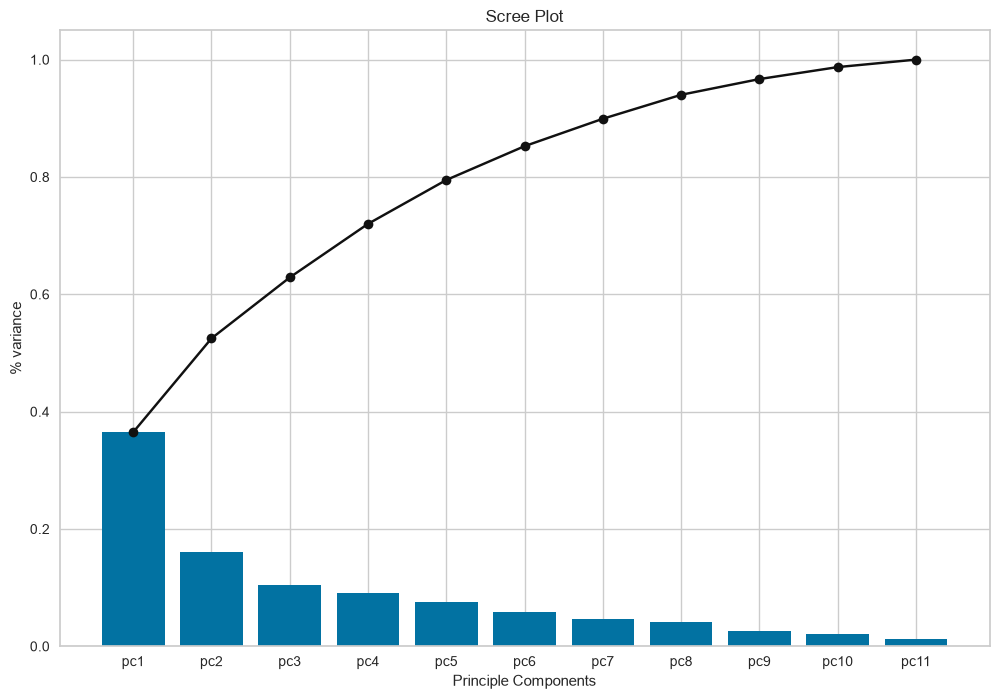

In [35]:
scree_plot(pca, [f'pc{i+1}' for i in range(len(df.columns))])

In [36]:
# Chọn số PC ít nhất giữ được 75% phương sai
n_pc = int(np.searchsorted(np.cumsum(pca.explained_variance_ratio_), 0.75) + 1)
pca_reduced = PCA(n_components=n_pc).fit(df)
pca_transformed_4d = pca_reduced.transform(df)
print('Số PC:', n_pc, '; phương sai giữ lại:', pca_reduced.explained_variance_ratio_.sum())
# Giữ tên biến của đề; số chiều thực tế được chọn theo phương sai.

Số PC: 5 ; phương sai giữ lại: 0.794812496041483


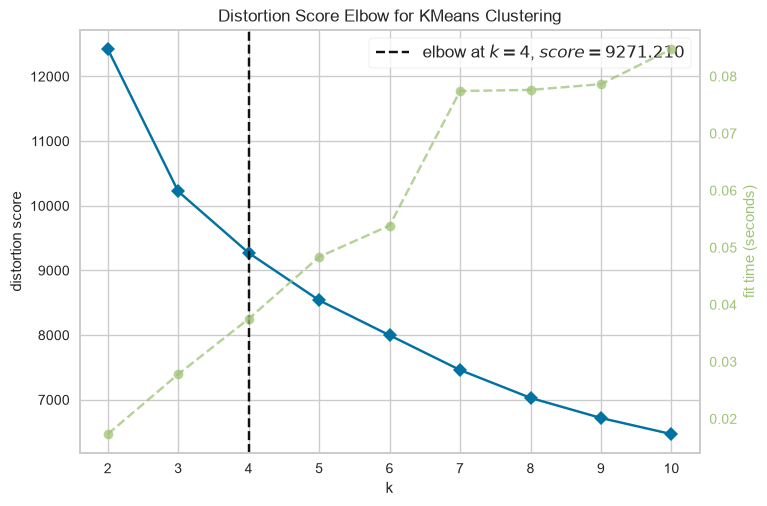

K trên dữ liệu PCA: 4


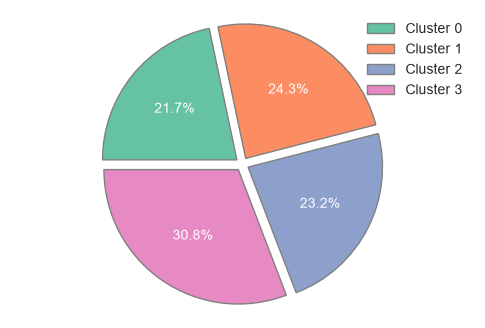

In [37]:
model = KMeans(n_init=20, random_state=99)
visualizer = KElbowVisualizer(model, k=10, force_model=True)
visualizer.fit(pca_transformed_4d)
visualizer.show()
K_pca = visualizer.elbow_value_ or 4
print('K trên dữ liệu PCA:', K_pca)
k_pca = KMeans(n_clusters=K_pca, n_init=10, random_state=3000).fit(pca_transformed_4d)
visualize_cluster_distribution(k_pca.labels_)

In [38]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_pca_df = customer_data.copy()
kmean_pca_df['Cluster'] = k_pca.labels_
kmean_pca_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,5148,1,0,1617,3
2174,1954,Graduation,1,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,4598,3,0,27,2
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,4797,2,0,776,3
6182,1984,Graduation,2,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,4624,3,0,53,1
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,4646,3,0,422,0


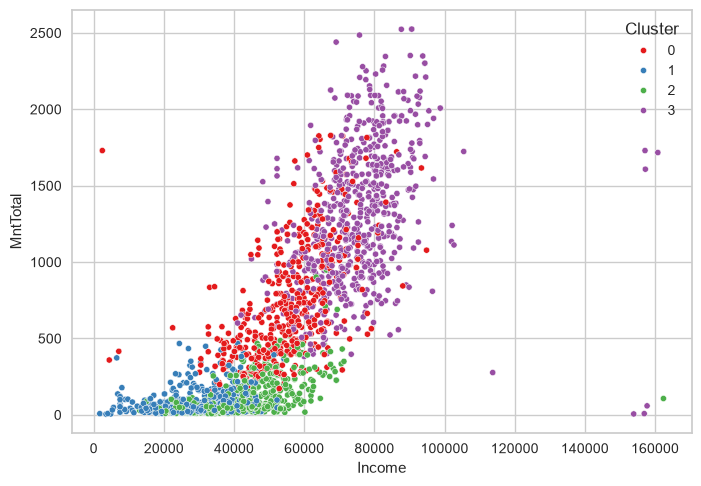

           Income  MntTotal  Fam_Size
Cluster                              
0        55430.11    724.72      3.03
1        28935.03     90.70      2.60
2        42505.34    129.18      3.13
3        74791.33   1287.66      1.89


In [39]:
sns.scatterplot(data=kmean_pca_df, x='Income', y='MntTotal', hue='Cluster', palette='Set1', s=20)
plt.show()
print(kmean_pca_df.groupby('Cluster')[['Income', 'MntTotal', 'Fam_Size']].mean().round(2))

#### A9. Phân tích kết quả phân cụm (DBSCAN)

In [40]:
from sklearn.cluster import DBSCAN

**Sử dụng knee plot để ước lượng eps**

In [41]:
len(df.columns)

11

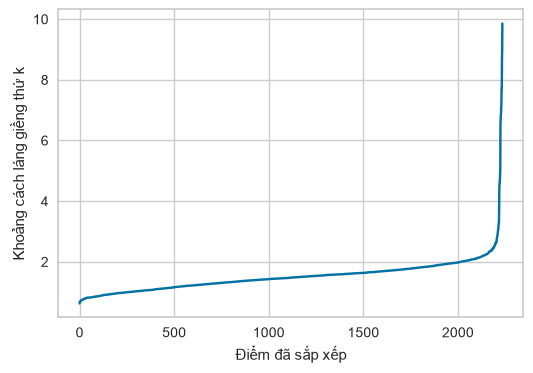

eps= 1.5 ; số cụm= 13 ; số nhiễu= 702
Silhouette bỏ nhiễu: -0.024


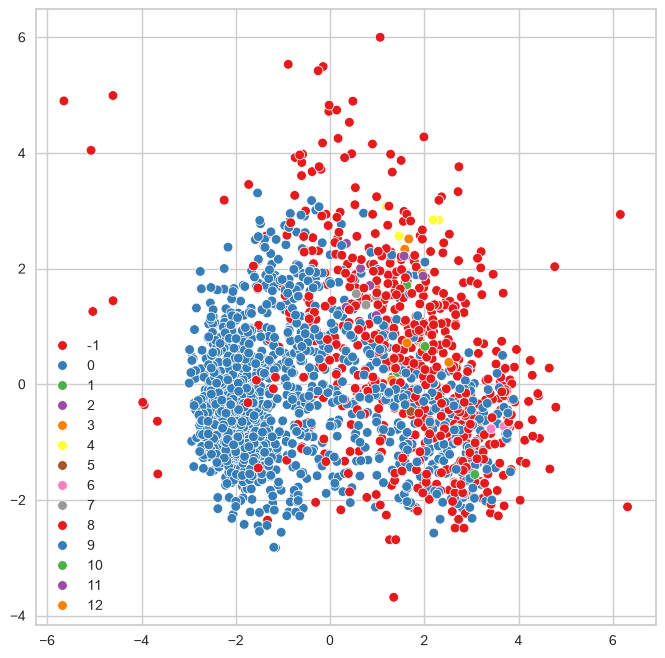

In [42]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

def knee_plot(n_neighs, data):
    distances, _ = NearestNeighbors(n_neighbors=n_neighs).fit(data).kneighbors(data)
    kth = np.sort(distances[:, -1])
    plt.figure(figsize=(6, 4))
    plt.plot(kth)
    plt.xlabel('Điểm đã sắp xếp')
    plt.ylabel('Khoảng cách láng giềng thứ k')
    plt.grid(True)
    plt.show()
    return kth

def dbscan_summary(data, eps, min_samples=5):
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(data)
    n_clusters = len(set(labels) - {-1})
    print('eps=', eps, '; số cụm=', n_clusters, '; số nhiễu=', np.sum(labels == -1))
    mask = labels != -1
    if 2 <= n_clusters < mask.sum():
        print('Silhouette bỏ nhiễu:', round(silhouette_score(np.asarray(data)[mask], labels[mask]), 3))
    else:
        print('Chưa đủ cụm hợp lệ để tính Silhouette bỏ nhiễu.')
    return labels

knee_plot(5, df)
db_labels = dbscan_summary(df, eps=1.5)
visualize_cluster_result(scores, db_labels)

**Sử dụng PCA thu giảm số chiều --> phân cụm**

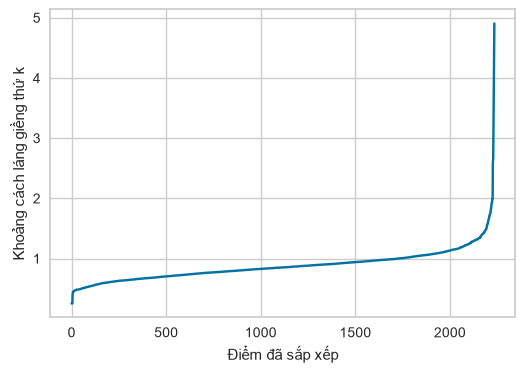

eps= 0.9 ; số cụm= 15 ; số nhiễu= 476
Silhouette bỏ nhiễu: -0.35


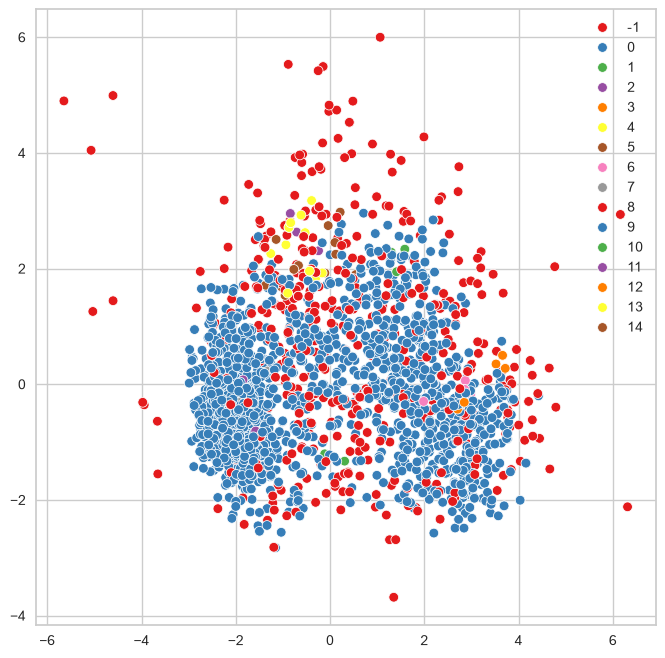

In [43]:
knee_plot(5, pca_transformed_4d)
db_pca_labels = dbscan_summary(pca_transformed_4d, eps=0.9)
visualize_cluster_result(scores, db_pca_labels)

**Chia nhỏ đặc trưng**

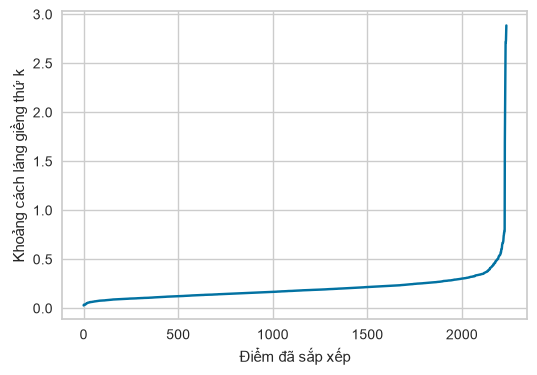

eps= 0.3 ; số cụm= 3 ; số nhiễu= 133
Silhouette bỏ nhiễu: 0.231


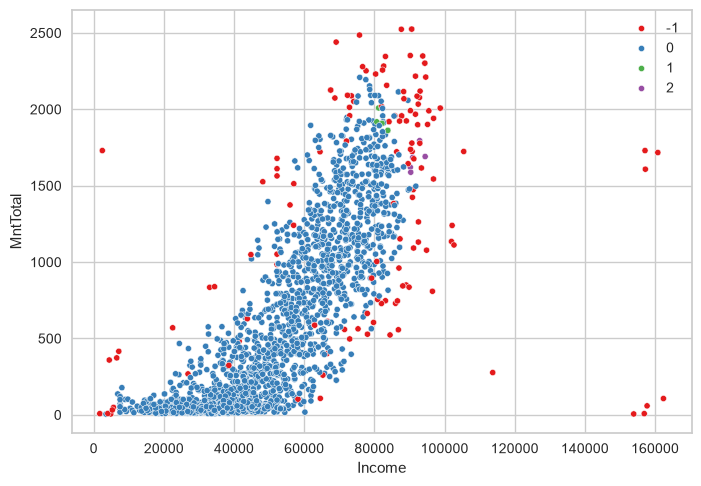

In [44]:
sub_df = df[['Income', 'MntTotal', 'Enroll_days']]
knee_plot(5, sub_df)
sub_labels = dbscan_summary(sub_df, eps=0.3)
sns.scatterplot(x=customer_data['Income'], y=customer_data['MntTotal'], hue=sub_labels, palette='Set1', s=20)
plt.show()

### B. Dữ liệu taxi 

In [45]:
import pandas as pd

In [46]:
df = pd.read_csv('data/taxi_data.csv')
print('Số dòng ban đầu:', len(df))
print('Tọa độ bị thiếu:', df[['LAT', 'LON']].isna().sum().to_dict())
df = df.dropna(subset=['LAT', 'LON']).copy()
df = df.loc[df['LAT'].between(-90, 90) & df['LON'].between(-180, 180)].copy()
df['NAME'] = df['NAME'].fillna('Unknown')
print('Số dòng còn lại:', len(df))
df.head()

Số dòng ban đầu: 838
Tọa độ bị thiếu: {'LAT': 1, 'LON': 1}
Số dòng còn lại: 837


,LON,LAT,NAME
0,28.17858,-25.73882,11th Street Taxi Rank
1,28.17660,-25.73795,81 Bazaar Street Taxi Rank
2,27.83239,-26.53722,Adams Road Taxi Rank
3,28.12514,-26.26666,Alberton City Mall Taxi Rank
4,28.10144,-26.10567,Alexandra Main Taxi Rank


**Biểu diễn giá trị toạ độ trên bản đồ**

In [47]:
import folium, re

In [48]:
X = df[['LAT', 'LON']].values
m = folium.Map(location=[X[:,0].mean(), X[:,1].mean()], tiles='OpenStreetMap', zoom_start=10)

In [49]:
for _,row in df.iterrows():
    folium.CircleMarker(
        location=[row.LAT,row.LON],
        radius=5,
        popup=re.sub(r'\W+',' ',row.NAME),
        fill=True
    ).add_to(m)

# Loại bỏ non-word chars
title = '''<h3 align="center" style="font-size:30px"><b>Given Data</b></h3>'''
m.get_root().html.add_child(folium.Element(title))
m

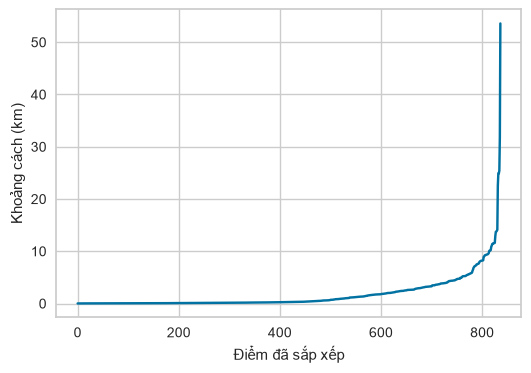

In [50]:
# Dùng haversine trên tọa độ radian để eps có ý nghĩa địa lý
X_rad = np.radians(X)
min_samples = 5
distances, _ = NearestNeighbors(n_neighbors=min_samples, metric='haversine', algorithm='ball_tree').fit(X_rad).kneighbors(X_rad)
plt.figure(figsize=(6, 4))
plt.plot(np.sort(distances[:, -1]) * 6371)
plt.ylabel('Khoảng cách (km)')
plt.xlabel('Điểm đã sắp xếp')
plt.grid(True)
plt.show()

In [51]:
#First create an array of color schemes
colors = ['royalblue', 'maroon', 'forestgreen', 'mediumorchid', 'tan', 'deeppink', 
          'olive', 'goldenrod', 'lightcyan', 'navy','springgreen','midnightblue',
         'red','brown','limegreen','lime','pink','orchid','crimson','m']*10

In [52]:
eps_km = 0.5
taxi_model = DBSCAN(eps=eps_km / 6371, min_samples=5, metric='haversine', algorithm='ball_tree')
df['Cluster'] = taxi_model.fit_predict(X_rad)
print('eps (km):', eps_km)
print('Số cụm:', len(set(df['Cluster']) - {-1}))
print('Số nhiễu:', (df['Cluster'] == -1).sum())
print(df['Cluster'].value_counts().sort_index())
df['Color'] = ['black' if c == -1 else colors[c % len(colors)] for c in df['Cluster']]

eps (km): 0.5
Số cụm: 49
Số nhiễu: 345
Cluster
-1     345
 0       8
 1       6
 2       7
 3       9
 4      12
 5       9
 6       6
 7       6
 8      13
 9       7
 10      9
 11     59
 12     10
 13      7
 14      7
 15      5
 16      5
 17     10
 18      8
 19      9
 20      7
 21      6
 22      6
 23      7
 24      7
 25      7
 26     15
 27     21
 28      7
 29     14
 30     18
 31     10
 32      7
 33     14
 34      6
 35     10
 36     26
 37      8
 38      5
 39     12
 40      7
 41      8
 42      7
 43      8
 44      5
 45     12
 46      5
 47     10
 48      5
Name: count, dtype: int64


In [53]:
def create_map(cluster_column, colors_column, title):
    m = folium.Map(location=[X[:,0].mean(),X[:,1].mean()],tiles='OpenStreetMap',zoom_start=8.5)
    for _,row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT,row.LON],
            radius=5,
            popup=str(row[cluster_column]),
            fill=True,
            color=row[colors_column],
            fill_color=row[colors_column],
        ).add_to(m)

    print(title)
    return m

In [54]:
create_map('Cluster', 'Color', 'DBSCAN taxi: đen là nhiễu')

DBSCAN taxi: đen là nhiễu


**Nhận xét:** KMeans gán mọi khách vào nhóm và có thể đọc bằng thu nhập, tổng chi tiêu, quy mô gia đình và kênh mua. Bảng trung bình cho biết nhóm nào chi nhiều; tên cụm chỉ là mã, không biểu thị thứ hạng. PCA giữ phần lớn phương sai với ít chiều hơn; nhãn sau PCA có thể khác vì các chiều ít phương sai đã bị bỏ. DBSCAN để điểm thưa thành nhiễu, kết quả nhạy với eps và số chiều. Với taxi, dùng khoảng cách địa lý haversine, eps=0.5 km để tìm vùng tập trung; điểm đen là vị trí chưa đủ mật độ. Bản đồ tương tác cần Internet để tải nền; nhãn và thống kê đã được lưu trong output.

DBSCAN trên toàn bộ feature và trên PCA có Silhouette âm trong lần chạy này: các nhóm còn chồng lấn, chưa phải cách chia tốt. Trên ba feature Income, MntTotal, Enroll_days, Silhouette dương nhưng còn thấp. Cần thử thêm eps và cân nhắc ý nghĩa feature nếu dùng thực tế. Taxi với eps=0.5 km cho 49 cụm và 345 điểm nhiễu; đây là các vùng nhỏ tập trung vị trí taxi.